In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt



In [2]:
# === Configuration ===
MODEL_PATH ="D:\CSP\cnn_transformer_helmet_detection_model.keras"  # Path to your saved model
IMG_SIZE = 224  # Input image size (same as training)

# === Load the model ===
try:
    model = load_model(MODEL_PATH)
    print(f"✅ Model loaded successfully from '{MODEL_PATH}'")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()



✅ Model loaded successfully from 'D:\CSP\cnn_transformer_helmet_detection_model.keras'


C:\Users\WINDOWS\AppData\Roaming\Python\Python311\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:

# === Preprocessing function ===
def preprocess_image(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found - {image_path}")
        return None
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0  # Resize and normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# === Prediction function ===
def predict_image(image_path, threshold=0.5):
    img = preprocess_image(image_path)
    if img is None:
        return None

    prediction_prob = model.predict(img)[0][0]  # Get prediction probability
    prediction_label = "Helmet Detected" if prediction_prob >= threshold else "No Helmet Detected"
    confidence = prediction_prob * 100 if prediction_prob >= threshold else (1 - prediction_prob) * 100

    # Display the image with prediction
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f"{prediction_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print(f"Prediction: {prediction_label} | Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


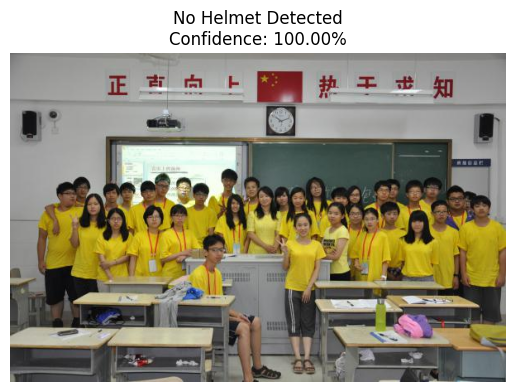

Prediction: No Helmet Detected | Confidence: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


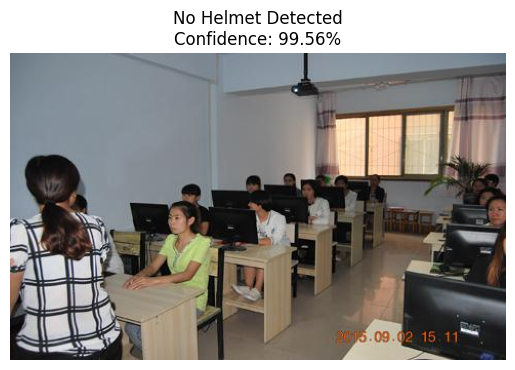

Prediction: No Helmet Detected | Confidence: 99.56%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


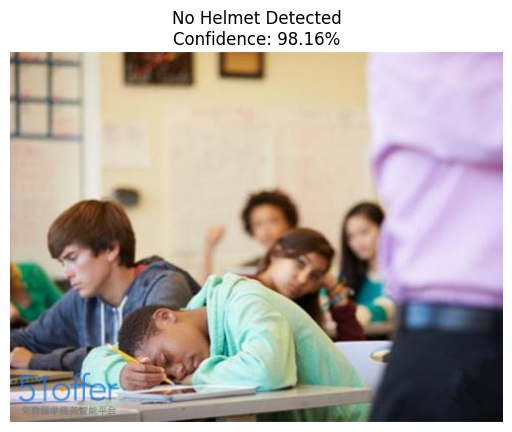

Prediction: No Helmet Detected | Confidence: 98.16%


In [6]:

# === Test multiple images ===
image_paths = [
    "D:\CSP\TestImages\PartB_00449.jpg",
"D:\CSP\TestImages\PartB_00450.jpg",
"D:\CSP\TestImages\PartB_00448.jpg"
]

# Run predictions on multiple images
for image_path in image_paths:
    predict_image(image_path)

In [7]:
print(model.input_shape)

(None, 224, 224, 3)
